# 04 - ResNet18 + Mahalanobis (não supervisionado) — metodologia corrigida

Modelo 3. Features de uma ResNet18 pré-treinada + distância de Mahalanobis.

> **Correção vs versão antiga:** antes o threshold era o ponto ótimo da ROC
> calculada **sobre as labels de teste** (leakage). Agora o threshold é o
> **quantil 0.95 dos scores das normais de validação** — sem ver o teste.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import torch
from utils import set_seed, get_device

set_seed(42)
device = get_device()
print("device:", device)

device: cuda


## 1. Extrair features (treino / validação / teste)

In [2]:
from bottle_protocol import bottle_train_good_paths, split_train_validation_good, bottle_test_records
from eval_resnet import build_resnet18_feature_extractor, extract_features, fit_mahalanobis, mahalanobis_scores

train_good = bottle_train_good_paths()
train_paths, val_paths = split_train_validation_good(train_good, val_fraction=0.2, seed=42)
registos = bottle_test_records()
test_paths = [r.path for r in registos]; test_labels = np.array([r.label for r in registos])

resnet, preprocess = build_resnet18_feature_extractor(device)
train_feats = extract_features(train_paths, resnet, preprocess, device)
val_feats = extract_features(val_paths, resnet, preprocess, device)
test_feats = extract_features(test_paths, resnet, preprocess, device)
print("Features:", train_feats.shape, val_feats.shape, test_feats.shape)

Features: (167, 512) (42, 512) (83, 512)


## 2. Ajustar distribuição normal e calibrar threshold na validação

In [3]:
from metrics import binary_classification_metrics, safe_auroc
import json

estimator = fit_mahalanobis(train_feats)
val_scores = mahalanobis_scores(estimator, val_feats)
threshold = float(np.quantile(val_scores, 0.95))   # calibrado na validação, não no teste

test_scores = mahalanobis_scores(estimator, test_feats)
metrics = binary_classification_metrics(test_labels, test_scores, threshold)
metrics["image_auroc"] = safe_auroc(test_labels, test_scores)
print(f"Threshold (validação q0.95): {threshold:.2f}")
print(json.dumps(metrics, indent=2))

Threshold (validação q0.95): 555.72
{
  "threshold": 555.7165087267307,
  "accuracy": 0.9759036144578314,
  "precision": 0.9692307692307692,
  "recall": 1.0,
  "f1": 0.984375,
  "image_auroc": 0.9968253968253968
}


## 3. Distribuição dos scores + threshold

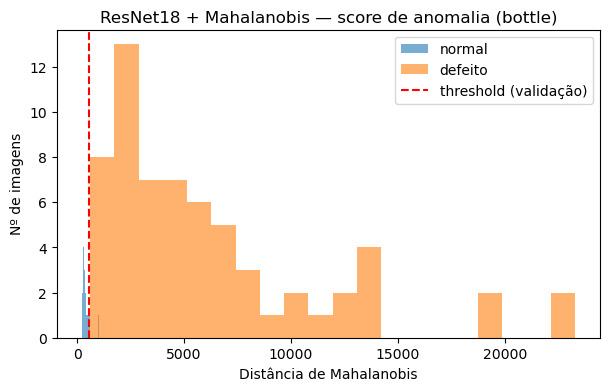

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(test_scores[test_labels == 0], bins=20, alpha=0.6, label="normal")
plt.hist(test_scores[test_labels == 1], bins=20, alpha=0.6, label="defeito")
plt.axvline(threshold, color="red", linestyle="--", label="threshold (validação)")
plt.xlabel("Distância de Mahalanobis"); plt.ylabel("Nº de imagens")
plt.title("ResNet18 + Mahalanobis — score de anomalia (bottle)"); plt.legend(); plt.show()

## 4. Exemplos com score (verde = acertou, vermelho = errou)

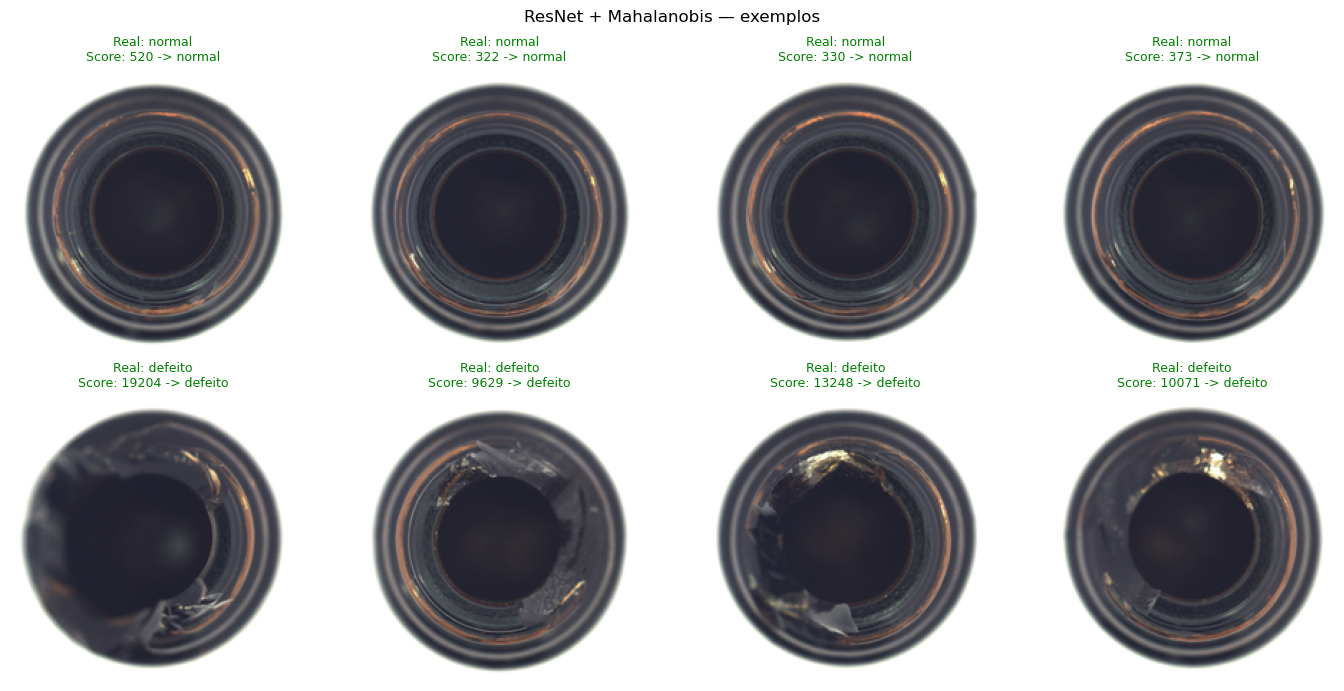

In [5]:
from PIL import Image
nomes = ["normal", "defeito"]
rng = np.random.default_rng(7)
nm = np.where(test_labels == 0)[0]; df = np.where(test_labels == 1)[0]
idx = np.concatenate([rng.choice(nm, 4, replace=False), rng.choice(df, 4, replace=False)])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), idx):
    prev = int(test_scores[i] > threshold)
    cor = "green" if prev == test_labels[i] else "red"
    ax.imshow(Image.open(test_paths[i]).convert("RGB").resize((200, 200))); ax.axis("off")
    ax.set_title(f"Real: {nomes[test_labels[i]]}\nScore: {test_scores[i]:.0f} -> {nomes[prev]}", color=cor, fontsize=9)
plt.suptitle("ResNet + Mahalanobis — exemplos"); plt.tight_layout(); plt.show()

## 5. Resumo por categoria (todas as categorias)

A ResNet+Mahalanobis foi aplicada às 5 categorias pelo
`scripts/train_resnet_category.py`. Aqui mostramos o AUROC/F1 por categoria
(lido de `results/resnet_summary.csv`).

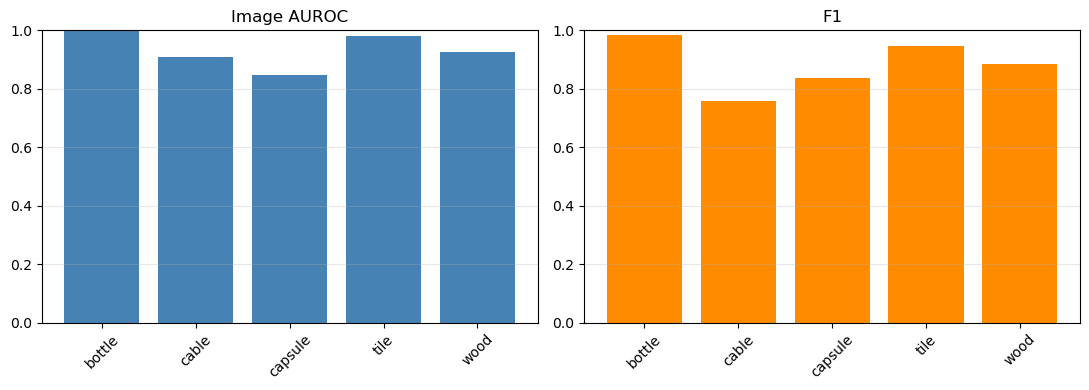

,category,accuracy,precision,recall,f1,image_auroc
0,bottle,0.9759,0.9692,1.0000,0.9844,0.9968
1,cable,0.7533,0.9508,0.6304,0.7582,0.9091
2,capsule,0.7576,0.9326,0.7615,0.8384,0.8456
3,tile,0.9231,0.9412,0.9524,0.9467,0.9812
4,wood,0.8101,0.8169,0.9667,0.8855,0.9254


In [6]:
import pandas as pd
caminho = ROOT / "results" / "resnet_summary.csv"
if caminho.exists():
    df = pd.read_csv(caminho)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(df["category"], df["image_auroc"], color="steelblue"); axes[0].set_title("Image AUROC"); axes[0].set_ylim(0, 1)
    axes[1].bar(df["category"], df["f1"], color="darkorange"); axes[1].set_title("F1"); axes[1].set_ylim(0, 1)
    for ax in axes:
        ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
    display(df.round(4))
else:
    print("[FALTA] results/resnet_summary.csv — corre scripts/train_resnet_category.py")